# Carga y exploración

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_freight_data, build_scenario, CITY_COORDS

sns.set_theme(style="whitegrid", palette="pastel")
df = load_freight_data()
print(f"Registros: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.describe().round(2)

Dataset ya disponible: ['fFreight.csv', 'freight_transformed.csv']

Archivo freight: ../data\fFreight.csv
Shape raw: (92060, 10)
Columnas raw: ['Date', 'Customer ID', 'Truck ID', 'Invoice Number', 'Freight ID', 'City', 'Net Revenue', 'Weight (Kg)', 'Weight (Cubic)', 'Goods Value']
Columnas detectadas: peso=weight_kg, vol=weight_cubic, ciudad=city, cliente=customer_id, revenue=net_revenue


c:\Users\ACER\Documents\logistics-vrp-real-data\notebooks\../src\data_loader.py:199: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["revenue"].fillna(df["peso_kg"] * 0.15, inplace=True)


Registros transformados: 3105
Peso promedio: 112.2 kg
Revenue promedio: $332

Dataset transformado guardado: freight_transformed.csv
Registros: 3105
Columnas: ['orden_id', 'cliente_id', 'ciudad_destino', 'cedi_id', 'peso_kg', 'vol_m3', 'revenue', 'fecha']


,peso_kg,vol_m3,revenue,fecha
count,3105.00,3105.00,64.00,3105
mean,112.23,162.09,332.36,2018-09-18 21:11:39.130434
min,1.00,1.00,1.00,2018-01-02 00:00:00
25%,1.00,1.00,4.50,2018-02-28 00:00:00
50%,6.00,9.00,42.00,2018-09-04 00:00:00
75%,27.00,43.00,361.25,2019-03-19 00:00:00
max,10200.00,12750.00,3664.00,2019-08-31 00:00:00
std,513.66,708.21,651.46,NaN


# Exploración

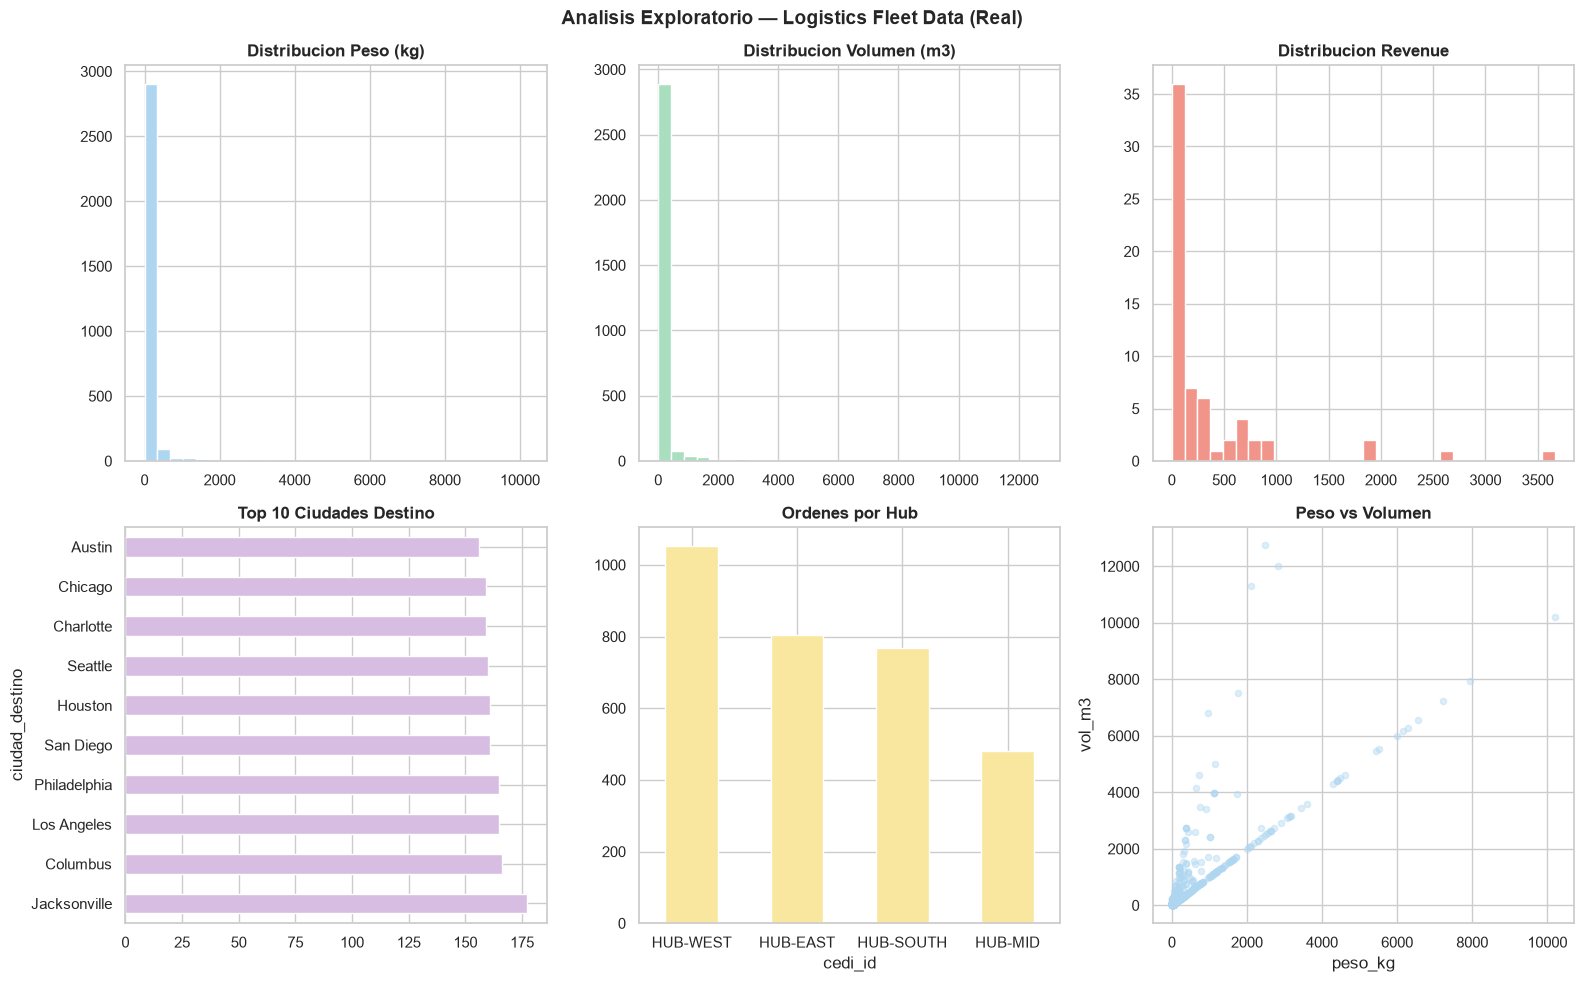

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df["peso_kg"].hist(bins=30, ax=axes[0,0], color="#AED6F1", edgecolor="white")
axes[0,0].set_title("Distribucion Peso (kg)", fontweight="bold")

df["vol_m3"].hist(bins=30, ax=axes[0,1], color="#A9DFBF", edgecolor="white")
axes[0,1].set_title("Distribucion Volumen (m3)", fontweight="bold")

if "revenue" in df.columns:
    df["revenue"].hist(bins=30, ax=axes[0,2], color="#F1948A", edgecolor="white")
    axes[0,2].set_title("Distribucion Revenue", fontweight="bold")

df["ciudad_destino"].value_counts().head(10).plot(
    kind="barh", ax=axes[1,0], color="#D7BDE2", edgecolor="white")
axes[1,0].set_title("Top 10 Ciudades Destino", fontweight="bold")

df["cedi_id"].value_counts().plot(
    kind="bar", ax=axes[1,1], color="#F9E79F", edgecolor="white", rot=0)
axes[1,1].set_title("Ordenes por Hub", fontweight="bold")

df.plot.scatter(x="peso_kg", y="vol_m3", ax=axes[1,2],
                alpha=0.4, color="#AED6F1")
axes[1,2].set_title("Peso vs Volumen", fontweight="bold")

plt.suptitle("Analisis Exploratorio — Logistics Fleet Data (Real)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_01_fleet.png", dpi=150, bbox_inches="tight")
plt.show()

# KPIs escenario base real

KPIs escenario base real:
  total_viajes: 21
  viajes_paqueteo: 21
  viajes_consolidados: 0
  costo_total: 8940770.61
  revenue_total: nan
  margen_total: nan
  peso_total_kg: 896.0
  vol_total_m3: 12.0
  dist_total_km: 9877.4
  ocup_peso_prom: 14.7
  ocup_vol_prom: 51.2
  costo_por_kg_prom: 88336.7229
  demanda_atendida_pct: 100.0
  clientes_por_viaje: 2.38


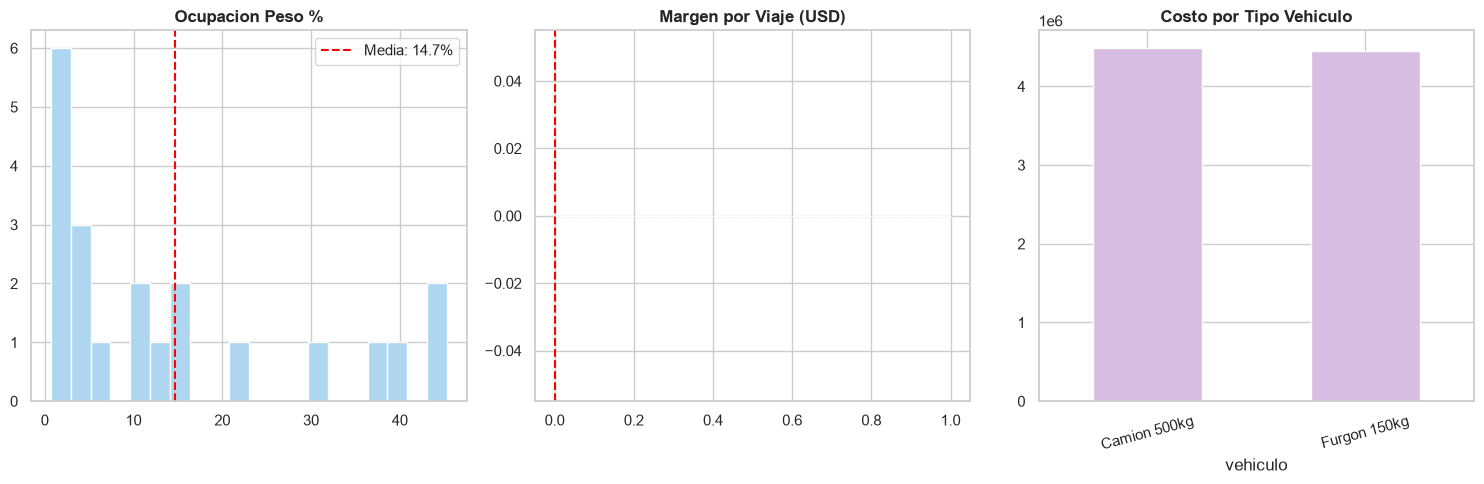

In [3]:
from optimizer import optimizar_escenario

scenario = build_scenario(df, n_orders=50, seed=42)
viajes, kpis = optimizar_escenario(scenario)
df_v = pd.DataFrame(viajes)

print("KPIs escenario base real:")
for k, v in kpis.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_v["ocup_peso_pct"].hist(bins=20, ax=axes[0], color="#AED6F1", edgecolor="white")
axes[0].set_title("Ocupacion Peso %", fontweight="bold")
axes[0].axvline(df_v["ocup_peso_pct"].mean(), color="red", linestyle="--",
                label=f"Media: {df_v['ocup_peso_pct'].mean():.1f}%")
axes[0].legend()

df_v["margen_viaje"].hist(bins=20, ax=axes[1], color="#A9DFBF", edgecolor="white")
axes[1].set_title("Margen por Viaje (USD)", fontweight="bold")
axes[1].axvline(0, color="red", linestyle="--")

df_v.groupby("vehiculo")["costo_total"].sum().plot(
    kind="bar", ax=axes[2], color="#D7BDE2", edgecolor="white", rot=15)
axes[2].set_title("Costo por Tipo Vehiculo", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/eda_02_vrp_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
df = load_freight_data()
print(df["peso_kg"].describe())

Dataset ya disponible: ['fFreight.csv', 'freight_transformed.csv']

Archivo freight: ../data\fFreight.csv
Shape raw: (92060, 10)
Columnas raw: ['Date', 'Customer ID', 'Truck ID', 'Invoice Number', 'Freight ID', 'City', 'Net Revenue', 'Weight (Kg)', 'Weight (Cubic)', 'Goods Value']
Columnas detectadas: peso=weight_kg, vol=weight_cubic, ciudad=city, cliente=customer_id, revenue=net_revenue


c:\Users\ACER\Documents\logistics-vrp-real-data\notebooks\../src\data_loader.py:199: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["revenue"].fillna(df["peso_kg"] * 0.15, inplace=True)


Registros transformados: 3105
Peso promedio: 112.2 kg
Revenue promedio: $332

Dataset transformado guardado: freight_transformed.csv
count     3105.00000
mean       112.23124
std        513.66386
min          1.00000
25%          1.00000
50%          6.00000
75%         27.00000
max      10200.00000
Name: peso_kg, dtype: float64
